# Week 01: Sunspot Butterfly Diagram

This notebook reads the provided sunspot group catalog and plots the classic solar "butterfly diagram" (latitude vs time of emergence).

## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [1]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

repo_path = "/content/butterflai"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cuda
   Seed     : 42


{'in_colab': True,
 'device': device(type='cuda'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [2]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/tmp/ipykernel_9453/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_9453/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

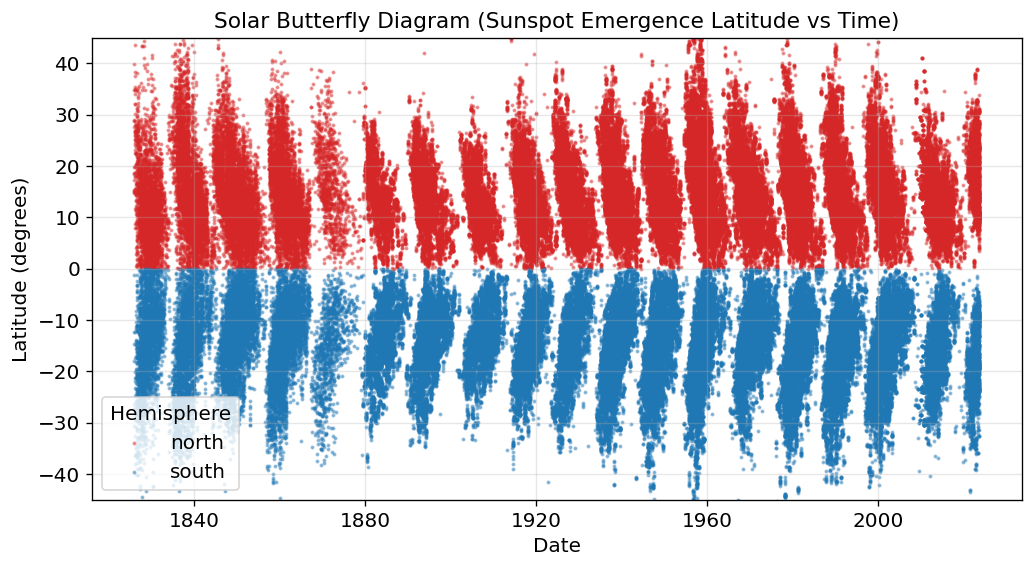

In [3]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:**
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


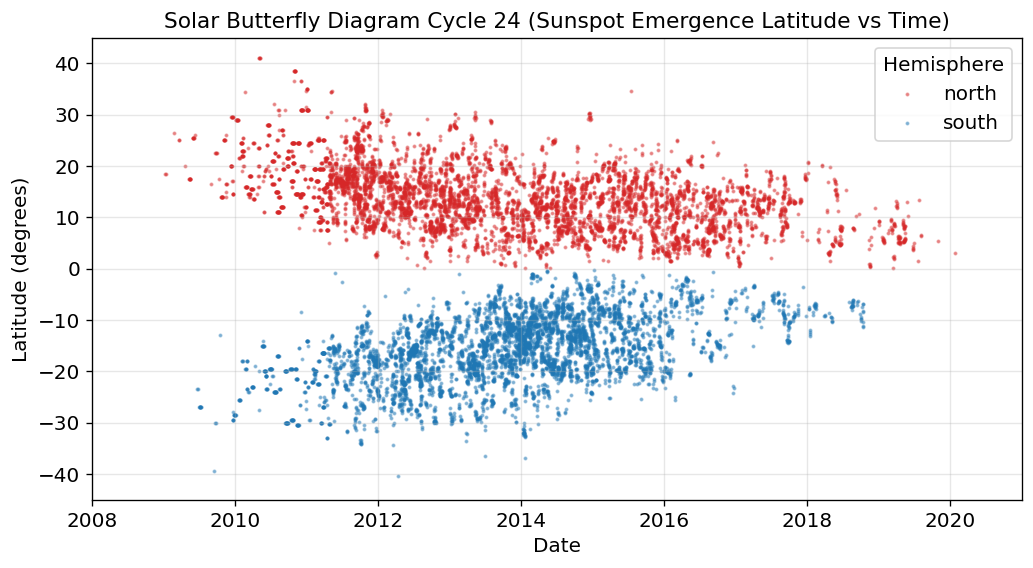

In [7]:
# Your code here: Visualize a single solar cycle
import matplotlib.pyplot as plt
from datetime import datetime

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

filtered_df = df[df["CYCLE"] == 24]

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in filtered_df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram Cycle 24 (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
ax.set_xlim(datetime(2008, 1, 1), datetime(2021, 1, 1))
plt.show()

## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


/tmp/ipykernel_9453/3114110238.py:10: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_mean = (df_indexed.groupby("hemisphere")["latitude"].resample("Y").mean().reset_index())


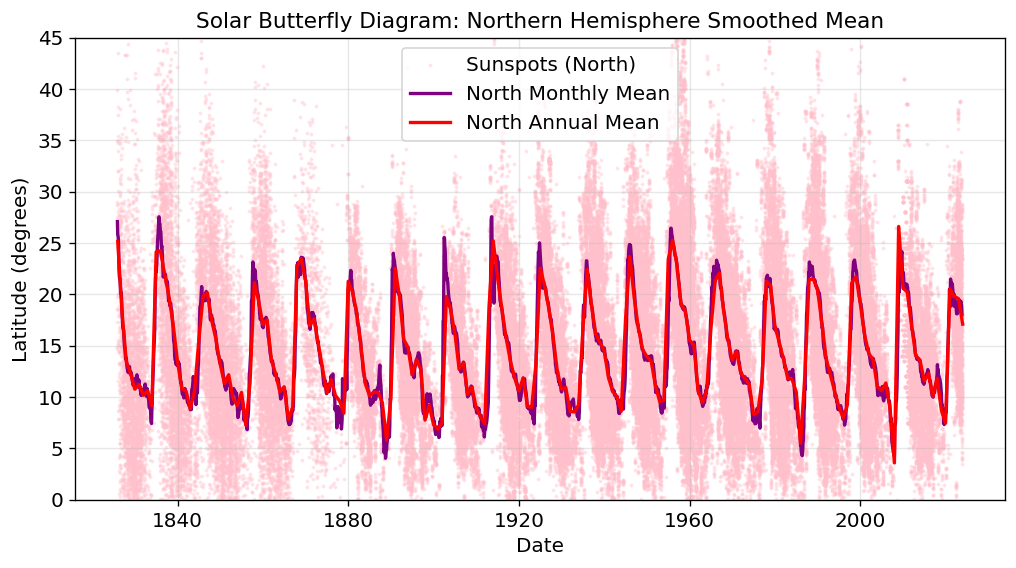

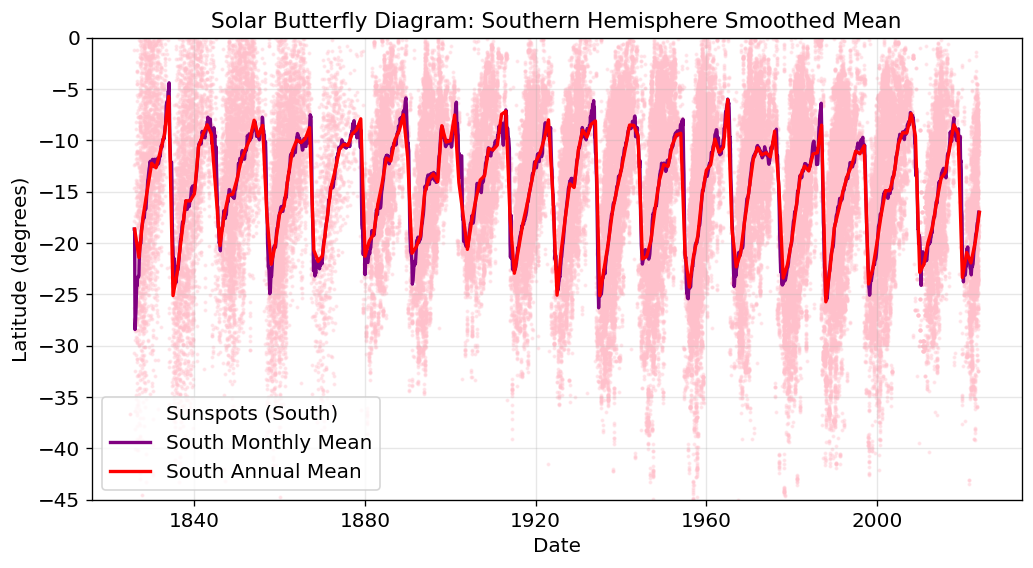

In [12]:
# Your code here: Calculate and plot mean latitudinal paths
import matplotlib.pyplot as plt
import pandas as pd

df_indexed = df.set_index("date")

# Monthly mean
monthly_mean = (df_indexed.groupby("hemisphere")["latitude"].resample("ME").mean().reset_index())
# Annual mean
annual_mean = (df_indexed.groupby("hemisphere")["latitude"].resample("Y").mean().reset_index())

monthly_mean["smoothed_latitude"] = monthly_mean.groupby("hemisphere")["latitude"].transform(lambda x: x.rolling(window=12, min_periods=1).mean())
annual_mean["smoothed_latitude"] = annual_mean.groupby("hemisphere")["latitude"].transform(lambda x: x.rolling(window=1, min_periods=1).mean())


for hemi in ["north", "south"]:
    fig, ax = plt.subplots(figsize=(10, 5))

    df_hemi = df_indexed[df_indexed["hemisphere"] == hemi]
    ax.scatter(df_hemi.index, df_hemi["latitude"], s=2, c="pink", alpha=0.3, label=f"Sunspots ({hemi.capitalize()})")

    subset_monthly = monthly_mean[monthly_mean["hemisphere"] == hemi]
    ax.plot(subset_monthly["date"], subset_monthly["smoothed_latitude"], color="purple", linewidth=2, label=f"{hemi.capitalize()} Monthly Mean")

    subset_annual = annual_mean[annual_mean["hemisphere"] == hemi]
    ax.plot(subset_annual["date"], subset_annual["smoothed_latitude"], color="red", linewidth=2, label=f"{hemi.capitalize()} Annual Mean")

    ax.set_title(f"Solar Butterfly Diagram: {hemi.capitalize()}ern Hemisphere Smoothed Mean")
    ax.set_xlabel("Date")
    ax.set_ylabel("Latitude (degrees)")

    if hemi == "north":
        ax.set_ylim(0, 45)
    else:
        ax.set_ylim(-45, 0)

    ax.legend()
    plt.show()

## 6) Reflection: Best Practices for AI-Assisted Learning

Throughout this program, you'll be working with AI assistants (like GitHub Copilot or Claude) to help with coding and understanding concepts.

**Task:**
- Ask your AI assistant: "What is the best way to prompt an AI assistant to help me learn machine learning and solar physics concepts effectively?"
- Write down their response and reflect: How will you apply this advice in future notebooks?

**Hint:** Be specific about what you want to learn and how you want the AI to explain it.


*Your reflection here:*

That's a great question! To effectively learn machine learning and solar physics concepts with an AI assistant, consider these strategies:

1. Be Specific and Clear: Instead of general questions like "Tell me about ML," ask targeted questions. For example: "Explain the core concepts of supervised learning in the context of predicting solar flare probability," or "How does a convolutional neural network (CNN) process images of the sun's surface?"
2. Provide Context: If you're working on a specific problem or have some prior knowledge, share it. "I'm trying to classify sunspot images; can you explain how feature extraction works in a deep learning model for this task?"
3. Break Down Complex Topics: For large concepts, ask the AI to break them into smaller, digestible parts. "Explain the solar dynamo in three main stages," or "What are the foundational mathematical concepts behind a Support Vector Machine (SVM)?"
4. Request Analogies and Examples: Ask for explanations using analogies or real-world examples, especially for abstract concepts. "Can you give me an analogy for how backpropagation works?" or "Provide an example of how transfer learning could be applied to solar data analysis."
5. Ask for Code Examples: If you're learning coding aspects, ask for code snippets or pseudo-code to illustrate concepts. "Show me a Python example of how to implement a simple linear regression model to predict solar cycle strength."
6. Iterative Learning: Don't be afraid to follow up with more questions based on the AI's previous answer. "You mentioned 'gradient descent'; can you elaborate on its role in optimizing a neural network?"
7. Identify Prerequisites: If you're stuck, ask the AI what foundational knowledge you might be missing. "What mathematical concepts should I understand before diving into quantum hydrodynamics in the sun's interior?"
8. Compare and Contrast: Ask the AI to compare different algorithms or theories. "What are the main differences between random forests and gradient boosting for predicting solar activity?" or "Compare the advantages and disadvantages of different solar magnetic field models."
9. Propose Scenarios/Problems: Ask the AI to walk you through a problem-solving scenario. "Imagine I have a dataset of solar wind parameters; how would I go about building a predictive model for geomagnetic storms using ML?"
10. Review and Reflect: After getting an explanation, try to summarize it in your own words, and then ask the AI to check your understanding. This active recall helps solidify learning.

By being precise and interactive, you can leverage the AI as a powerful personalized tutor.

How will you apply this advice in future notebooks?
I hope to make the AI assistant as a side-by-side tutor to me to help me learn along as I complete each notebook. I hope to use the AI assistant as a learning tool to ask conceptual questions and prior foundational knowledge required about solar cycles or neural network back propogation techniques. In addition to this, I hope to learn more about pandas and other programming/ML research techniques. If I were to get stuck on problems, I would treat the AI assistant as a guide to help me think towards the right direction instead of spilling the answers immediately while not fueling my brain with foundational knowledge for this research project, even if it was a small bug like a typo. Finally, at the end of each notebook, I hope to organize my thoughts with the assistant and create and understand a list of takeaways of this project which I could potentially use for other ML projects outside of ButterflAI and other future real-world projects.

